### dataset (2015–2022) 

Xtinoume paper-aligned features + target

Kanoume time-based split (train/test) opws sto paper


In [1]:
import pandas as pd
from pathlib import Path

# Project root (to notebook einai mesa se /jupyter_notebook)
ROOT = Path.cwd().parent

INTERIM_DIR = ROOT / "API-Data" / "interim"
PROCESSED_DIR = ROOT / "API-Data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IN_CSV = INTERIM_DIR / "inspections_2015_2022_flat.csv"

print("Reading:", IN_CSV)

df = pd.read_csv(IN_CSV)

print("\nRows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

print("\nSample rows:")
display(df.head(3))


Reading: C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\interim\inspections_2015_2022_flat.csv

Rows: 134842
Columns: 18
['InspectionID', 'ReportingAuthority', 'PlaceOfInspection', 'DateOfFirstVisit', 'DateOfFinalVisit', 'PSCInspectionType', 'IMO', 'Flag', 'ShipType', 'KeelDate', 'GrossTonnage', 'ClassIssuingAuthority', 'ISMCompanyIMO', 'ISMCompanyCountry', 'TotalDeficiencies', 'DefectiveItemCodes', 'DurationOfDetention', 'SourceYearZip']

Sample rows:


,InspectionID,ReportingAuthority,PlaceOfInspection,DateOfFirstVisit,DateOfFinalVisit,PSCInspectionType,IMO,Flag,ShipType,KeelDate,GrossTonnage,ClassIssuingAuthority,ISMCompanyIMO,ISMCompanyCountry,TotalDeficiencies,DefectiveItemCodes,DurationOfDetention,SourceYearZip
0,387577741,NL,NLRTM,2015-01-16Z,2015-01-16Z,INITIAL_INSPECTION,9374014,MT,330,2005-06-05Z,3988,115.0,4084552.0,TR,5,03104|03108|03107|11113|02108,0,THETIS_PSC_2015_inspections.zip
1,387579352,IT,ITCHI,2015-01-16Z,2015-01-22Z,DETAILED_INSPECTION,9559169,MD,360,2008-05-08Z,3068,212.0,5048711.0,UA,15,01101|11135|05107|10114|04103|10123|07115|0711...,7,THETIS_PSC_2015_inspections.zip
2,387577674,NL,NLRTM,2015-01-16Z,2015-01-16Z,DETAILED_INSPECTION,9433456,AG,353,2008-03-19Z,7464,132.0,4022178.0,DE,2,11124|13102,0,THETIS_PSC_2015_inspections.zip


### Basic cleaning & types

- Metatrepoume imerominies se datetime (DateOfFirstVisit, KeelDate)
- Metatrepoume arithmitika fields se numeric (GrossTonnage, TotalDeficiencies, DurationOfDetention)
- Kanoume grigorous elegxous gia missing values


In [2]:
import numpy as np

# 1) Dates: sto dataset mas kapoies fores einai typou "2022-04-01Z"
def parse_date_z(s):
    s = s.astype(str).str.replace("Z", "", regex=False)
    return pd.to_datetime(s, errors="coerce")

df["DateOfFirstVisit_dt"] = parse_date_z(df["DateOfFirstVisit"])
df["KeelDate_dt"] = parse_date_z(df["KeelDate"])

# 2) Numerics
df["GrossTonnage_num"] = pd.to_numeric(df["GrossTonnage"], errors="coerce")
df["TotalDeficiencies_num"] = pd.to_numeric(df["TotalDeficiencies"], errors="coerce").fillna(0).astype(int)
df["DurationOfDetention_num"] = pd.to_numeric(df["DurationOfDetention"], errors="coerce").fillna(0).astype(int)

# 3) Quick checks
print("Missing DateOfFirstVisit_dt:", df["DateOfFirstVisit_dt"].isna().sum())
print("Missing KeelDate_dt:", df["KeelDate_dt"].isna().sum())
print("Missing GrossTonnage_num:", df["GrossTonnage_num"].isna().sum())

print("\nDurationOfDetention_num (top 10 counts):")
print(df["DurationOfDetention_num"].value_counts().head(10))

print("\nNon-zero detentions:", (df["DurationOfDetention_num"] > 0).sum())


Missing DateOfFirstVisit_dt: 0
Missing KeelDate_dt: 1
Missing GrossTonnage_num: 0

DurationOfDetention_num (top 10 counts):
DurationOfDetention_num
0    130373
3       599
4       567
5       479
2       435
6       359
7       335
8       273
9       188
1       153
Name: count, dtype: int64

Non-zero detentions: 4469


### μεταβλητής-στόχου (duration_class) και έλεγχος ανισορροπίας κλάσεων

Μετατρέπουμε τη διάρκεια κράτησης (σε ημέρες) σε 9 κλάσεις (όπως στο paper)
- Υπολογίζουμε την κατανομή των κλάσεων (counts και ποσοστά)
- Ελέγχουμε αν υπάρχει class imbalance / multi-class imbalance


In [3]:
# Binning tou target se 9 classes (paper-aligned)
def bin_duration(d):
    if d <= 0:
        return "0 day"
    if d <= 2:
        return "1-2 days"
    if d == 3:
        return "3 days"
    if d == 4:
        return "4 days"
    if d == 5:
        return "5 days"
    if d <= 7:
        return "6-7 days"
    if d <= 10:
        return "8-10 days"
    if d <= 17:
        return "11-17 days"
    return "18+ days"

df["duration_class"] = df["DurationOfDetention_num"].apply(bin_duration)

# Class distribution (multi-class imbalance)
counts = df["duration_class"].value_counts()
perc = (counts / counts.sum() * 100).round(2)

print("Class distribution (counts):")
print(counts)

print("\nClass distribution (percent %):")
print(perc)

# Quick imbalance indicators
majority_pct = perc.iloc[0]
minority_pct = perc.iloc[-1]
print("\nMajority class %:", majority_pct)
print("Minority class %:", minority_pct)
print("Imbalance ratio (majority/minority):", round(counts.iloc[0] / counts.iloc[-1], 2))


Class distribution (counts):
duration_class
0 day         130373
6-7 days         694
3 days           599
8-10 days        589
1-2 days         588
4 days           567
11-17 days       503
5 days           479
18+ days         450
Name: count, dtype: int64

Class distribution (percent %):
duration_class
0 day         96.69
6-7 days       0.51
3 days         0.44
8-10 days      0.44
1-2 days       0.44
4 days         0.42
11-17 days     0.37
5 days         0.36
18+ days       0.33
Name: count, dtype: float64

Majority class %: 96.69
Minority class %: 0.33
Imbalance ratio (majority/minority): 289.72


C:\Users\georg\AppData\Local\Temp\ipykernel_25840\175737541.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


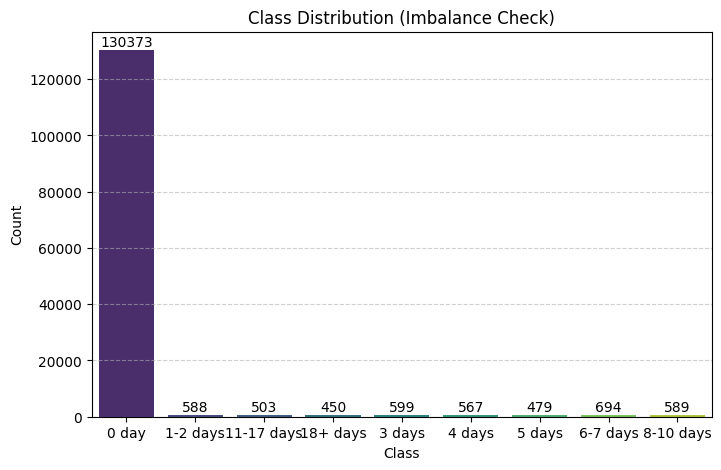

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df["duration_class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)

for i, v in enumerate(class_counts.values):
    plt.text(i, v + max(class_counts.values)*0.01, str(v), ha="center")

plt.show()


### Υπολογισμός ηλικίας πλοίου και κατηγοριοποίηση (Ship Age Groups)

Υπολογίζουμε την ηλικία του πλοίου (σε έτη) κατά την επιθεώρηση
- Ομαδοποιούμε την ηλικία σε κατηγορίες όπως στο paper:
  0–4, 5–9, 10–14, 15–19, 20+


In [5]:
df["ship_age_years"] = (
    (df["DateOfFirstVisit_dt"] - df["KeelDate_dt"])
    .dt.days / 365.25
)

# Binning ilikias opws sto paper
def bin_ship_age(age):
    if pd.isna(age) or age < 0:
        return "unknown"
    if age <= 4:
        return "0-4"
    if age <= 9:
        return "5-9"
    if age <= 14:
        return "10-14"
    if age <= 19:
        return "15-19"
    return "20+"

df["ship_age_group"] = df["ship_age_years"].apply(bin_ship_age)

# Katanoμή ilikias
age_counts = df["ship_age_group"].value_counts()
age_perc = (age_counts / age_counts.sum() * 100).round(2)

print("Ship age group distribution (counts):")
print(age_counts)

print("\nShip age group distribution (%):")
print(age_perc)

Ship age group distribution (counts):
ship_age_group
20+        39939
10-14      33592
5-9        29443
15-19      21316
0-4        10551
unknown        1
Name: count, dtype: int64

Ship age group distribution (%):
ship_age_group
20+        29.62
10-14      24.91
5-9        21.84
15-19      15.81
0-4         7.82
unknown     0.00
Name: count, dtype: float64


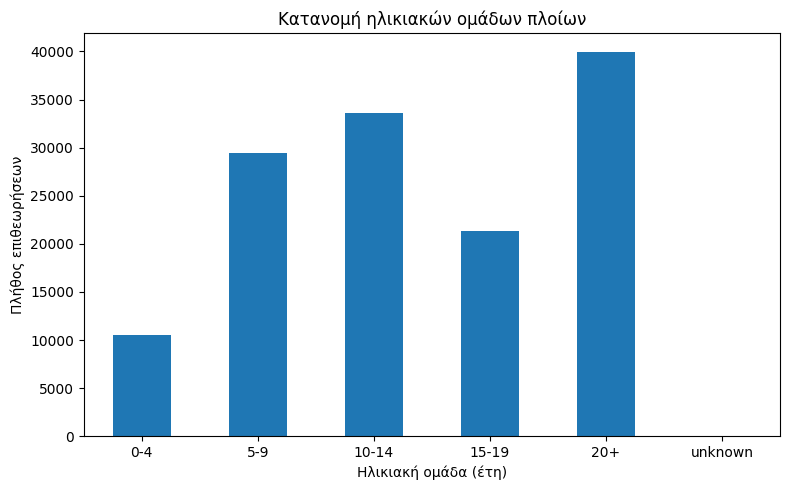

In [6]:
age_order = ["0-4", "5-9", "10-14", "15-19", "20+", "unknown"]

age_counts_ordered = age_counts.reindex(age_order)

plt.figure(figsize=(8, 5))
age_counts_ordered.plot(kind="bar")

plt.title("Κατανομή ηλικιακών ομάδων πλοίων")
plt.xlabel("Ηλικιακή ομάδα (έτη)")
plt.ylabel("Πλήθος επιθεωρήσεων")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Κατηγοριοποίηση ολικής χωρητικότητας πλοίων (Gross Tonnage Groups)

Μετατρέπουμε την ολική χωρητικότητα (Gross Tonnage) σε κατηγορίες
  σύμφωνα με το paper:
  <500, 500–1999, 2000–9999, 10000+


In [7]:
# Binning Gross Tonnage opws sto paper
def bin_gross_tonnage(gt):
    if pd.isna(gt) or gt <= 0:
        return "unknown"
    if gt < 500:
        return "<500"
    if gt < 2000:
        return "500-1999"
    if gt < 10000:
        return "2000-9999"
    return "10000+"

df["gt_group"] = df["GrossTonnage_num"].apply(bin_gross_tonnage)

# Katanoμή GT groups
gt_counts = df["gt_group"].value_counts()
gt_perc = (gt_counts / gt_counts.sum() * 100).round(2)

print("Gross Tonnage group distribution (counts):")
print(gt_counts)

print("\nGross Tonnage group distribution (%):")
print(gt_perc)


Gross Tonnage group distribution (counts):
gt_group
10000+       75767
2000-9999    44238
500-1999      8823
<500          6013
unknown          1
Name: count, dtype: int64

Gross Tonnage group distribution (%):
gt_group
10000+       56.19
2000-9999    32.81
500-1999      6.54
<500          4.46
unknown       0.00
Name: count, dtype: float64


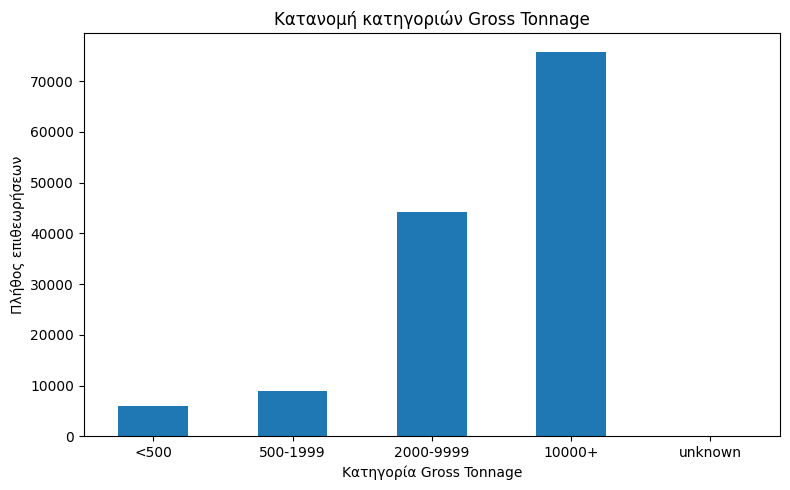

In [8]:
gt_order = ["<500", "500-1999", "2000-9999", "10000+", "unknown"]
gt_counts_ordered = gt_counts.reindex(gt_order)

plt.figure(figsize=(8, 5))
gt_counts_ordered.plot(kind="bar")

plt.title("Κατανομή κατηγοριών Gross Tonnage")
plt.xlabel("Κατηγορία Gross Tonnage")
plt.ylabel("Πλήθος επιθεωρήσεων")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Μετατροπή ελλείψεων (DefectiveItemCodes) σε 17 κατηγορίες (binary features)

- Από τη στήλη `DefectiveItemCodes` δημιουργούμε μεταβλητές που δείχνουν αν μία επιθεώρηση είχε έλλειψη σε κάθε μία από τις 17 ομάδες ελλείψεων.
- Κάθε νέα στήλη είναι δυαδική (0/1): π.χ. `def_grp_01`, `def_grp_02`, ..., `def_grp_17`.
- Αυτό είναι paper-aligned προσέγγιση, γιατί κρατάμε σταθερό σετ χαρακτηριστικών


In [9]:
# Ftiaxnoume 17 fixed deficiency groups (01..17)
DEF_GROUPS = [f"{i:02d}" for i in range(1, 18)]

# Extract function: apo string "01108|07106|18420" kratame ta 2 prwta digits (01,07,18)
def extract_def_groups(codes_str):
    if not isinstance(codes_str, str) or codes_str.strip() == "":
        return set()

    groups = set()
    parts = codes_str.split("|")

    for c in parts:
        c = c.strip()
        if len(c) >= 2 and c[0:2].isdigit():
            groups.add(c[0:2])

    return groups

# Apply se kathe grammi
df["def_groups_set"] = df["DefectiveItemCodes"].apply(extract_def_groups)

# Ftiaxnoume binary columns gia tis 17 omades
for g in DEF_GROUPS:
    df[f"def_grp_{g}"] = df["def_groups_set"].apply(lambda s: 1 if g in s else 0).astype(int)

print("Created deficiency group columns:", [f"def_grp_{g}" for g in DEF_GROUPS][:5], "...")

# Quick check: posa inspections exoun touλάχιστον mia ellipsi se kapoia apo tis 17 omades
df["has_def_in_01_17"] = df[[f"def_grp_{g}" for g in DEF_GROUPS]].sum(axis=1) > 0
print("Rows with at least one deficiency group (01-17):", df["has_def_in_01_17"].sum())
print("Rows with NO deficiency group (01-17):", (~df["has_def_in_01_17"]).sum())


Created deficiency group columns: ['def_grp_01', 'def_grp_02', 'def_grp_03', 'def_grp_04', 'def_grp_05'] ...
Rows with at least one deficiency group (01-17): 67368
Rows with NO deficiency group (01-17): 67474


Deficiency group counts (01-17):
01    27534
02    12044
03    11187
04    13991
05     5886
06     1587
07    26728
08     2554
09     2725
10    22998
11    18193
12      442
13    10439
14    15193
15    14423
16        0
17        0
dtype: int64


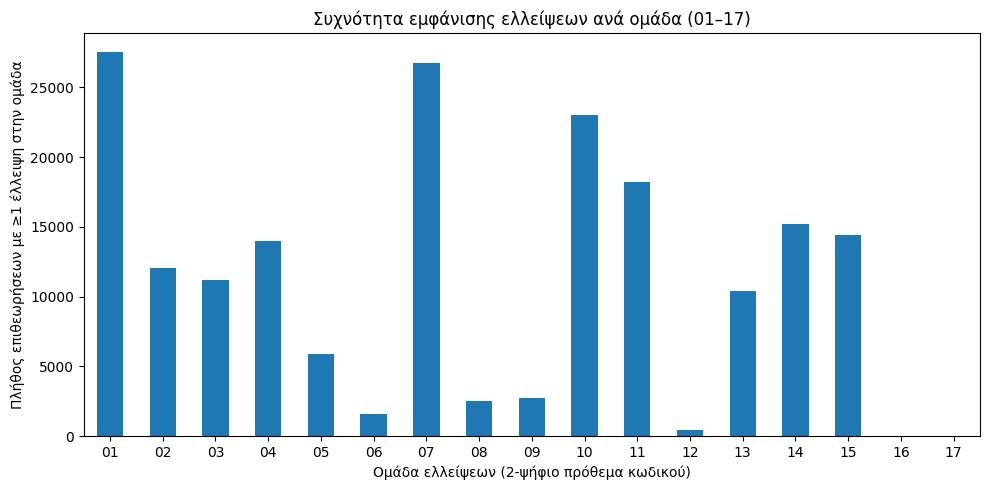

In [10]:
# Poses epitheoriseis exoun deficiency se kathe group (sum twn 0/1)
def_group_counts = {}
for g in DEF_GROUPS:
    col = f"def_grp_{g}"
    def_group_counts[g] = int(df[col].sum())

# Metatrepoume se Series gia eukolo plot
def_counts_series = pd.Series(def_group_counts).sort_index()

print("Deficiency group counts (01-17):")
print(def_counts_series)

plt.figure(figsize=(10, 5))
def_counts_series.plot(kind="bar")

plt.title("Συχνότητα εμφάνισης ελλείψεων ανά ομάδα (01–17)")
plt.xlabel("Ομάδα ελλείψεων (2-ψήφιο πρόθεμα κωδικού)")
plt.ylabel("Πλήθος επιθεωρήσεων με ≥1 έλλειψη στην ομάδα")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Δημιουργία τελικού dataset (paper-aligned features)

Επιλέγουμε τα χαρακτηριστικά που χρησιμοποιούνται στο paper
- Αφαιρούμε αναγνωριστικά (IDs) και βοηθητικές στήλες
- Δημιουργούμε το τελικό dataset που θα χρησιμοποιηθεί από τους αλγορίθμους ML


In [11]:
# Target
TARGET = "duration_class"

# Categorical predictors (paper-style)
categorical_features = [
    "Flag",
    "ShipType",
    "PSCInspectionType",
    "PlaceOfInspection",
    "ReportingAuthority",
    "ship_age_group",
    "gt_group",
]

# Deficiency group binary features (01..17)
def_features = [f"def_grp_{g}" for g in DEF_GROUPS]

# Teliko set features
FEATURES = categorical_features + def_features

print("Total features:", len(FEATURES))
print("Features:")
for f in FEATURES:
    print(" -", f)

# Kratame mono ta apaitoumena columns
df_model = df[FEATURES + [TARGET, "DateOfFirstVisit_dt"]].copy()

print("\nFinal dataset shape:", df_model.shape)
print("\nSample rows:")
display(df_model.head(3))


Total features: 24
Features:
 - Flag
 - ShipType
 - PSCInspectionType
 - PlaceOfInspection
 - ReportingAuthority
 - ship_age_group
 - gt_group
 - def_grp_01
 - def_grp_02
 - def_grp_03
 - def_grp_04
 - def_grp_05
 - def_grp_06
 - def_grp_07
 - def_grp_08
 - def_grp_09
 - def_grp_10
 - def_grp_11
 - def_grp_12
 - def_grp_13
 - def_grp_14
 - def_grp_15
 - def_grp_16
 - def_grp_17

Final dataset shape: (134842, 26)

Sample rows:


,Flag,ShipType,PSCInspectionType,PlaceOfInspection,ReportingAuthority,ship_age_group,gt_group,def_grp_01,def_grp_02,def_grp_03,...,def_grp_10,def_grp_11,def_grp_12,def_grp_13,def_grp_14,def_grp_15,def_grp_16,def_grp_17,duration_class,DateOfFirstVisit_dt
0,MT,330,INITIAL_INSPECTION,NLRTM,NL,10-14,2000-9999,0,1,1,...,0,1,0,0,0,0,0,0,0 day,2015-01-16
1,MD,360,DETAILED_INSPECTION,ITCHI,IT,5-9,2000-9999,1,0,0,...,1,1,0,0,0,1,0,0,6-7 days,2015-01-16
2,AG,353,DETAILED_INSPECTION,NLRTM,NL,5-9,2000-9999,0,0,0,...,0,1,0,1,0,0,0,0,0 day,2015-01-16


### ΔΕΝ κρατήσαμε

- InspectionID, IMO → IDs (no predictive value)
- KeelDate, GrossTonnage → raw values (έχουν γίνει bins)
- DefectiveItemCodes → raw text (έγινε σε groups)
- SourceYearZip → debugging only

### διαχωρισμός Train/Test και έλεγχος ανισορροπίας κλάσεων

Διαχωρίζουμε το dataset σε train και test με βάση τον χρόνο -> Ακολουθούμε ακριβώς το split του paper:
  - Train: έως 31/03/2022
  - Test: 01/04/2022 έως 31/08/2022

Ελέγχουμε την κατανομή της μεταβλητής-στόχου (duration_class ξεχωριστά για train και test)


In [12]:
# Orismos xronikou split (paper-aligned)
TRAIN_END = pd.Timestamp("2022-03-31")
TEST_START = pd.Timestamp("2022-04-01")
TEST_END = pd.Timestamp("2022-08-31")

# Train / Test split me vasi tin imerominia epitheorisis
train_df = df_model[df_model["DateOfFirstVisit_dt"] <= TRAIN_END].copy()
test_df = df_model[
    (df_model["DateOfFirstVisit_dt"] >= TEST_START) &
    (df_model["DateOfFirstVisit_dt"] <= TEST_END)
].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

# Afairoume to DateOfFirstVisit_dt apo ta features (den xreiazetai sto ML)
train_df = train_df.drop(columns=["DateOfFirstVisit_dt"])
test_df = test_df.drop(columns=["DateOfFirstVisit_dt"])


Train rows: 122002
Test rows: 7483


### Κατανομή κλάσεων στο Train και στο Test σύνολο

Στο σημείο αυτό εξετάζουμε αν η ανισορροπία κλάσεων (multi-class imbalance)παραμένει τόσο στο σύνολο εκπαίδευσης όσο και στο σύνολο ελέγχου.


In [13]:
# Class distribution sto train
train_counts = train_df[TARGET].value_counts()
train_perc = (train_counts / train_counts.sum() * 100).round(2)

# Class distribution sto test
test_counts = test_df[TARGET].value_counts()
test_perc = (test_counts / test_counts.sum() * 100).round(2)

print("=== Train class distribution (counts) ===")
print(train_counts)
print("\n=== Train class distribution (%) ===")
print(train_perc)

print("\n=== Test class distribution (counts) ===")
print(test_counts)
print("\n=== Test class distribution (%) ===")
print(test_perc)


=== Train class distribution (counts) ===
duration_class
0 day         118063
6-7 days         613
3 days           544
1-2 days         536
4 days           513
8-10 days        509
11-17 days       426
5 days           426
18+ days         372
Name: count, dtype: int64

=== Train class distribution (%) ===
duration_class
0 day         96.77
6-7 days       0.50
3 days         0.45
1-2 days       0.44
4 days         0.42
8-10 days      0.42
11-17 days     0.35
5 days         0.35
18+ days       0.30
Name: count, dtype: float64

=== Test class distribution (counts) ===
duration_class
0 day         7174
18+ days        50
11-17 days      49
6-7 days        46
8-10 days       43
4 days          33
3 days          30
5 days          30
1-2 days        28
Name: count, dtype: int64

=== Test class distribution (%) ===
duration_class
0 day         95.87
18+ days       0.67
11-17 days     0.65
6-7 days       0.61
8-10 days      0.57
4 days         0.44
3 days         0.40
5 days         0.40
1

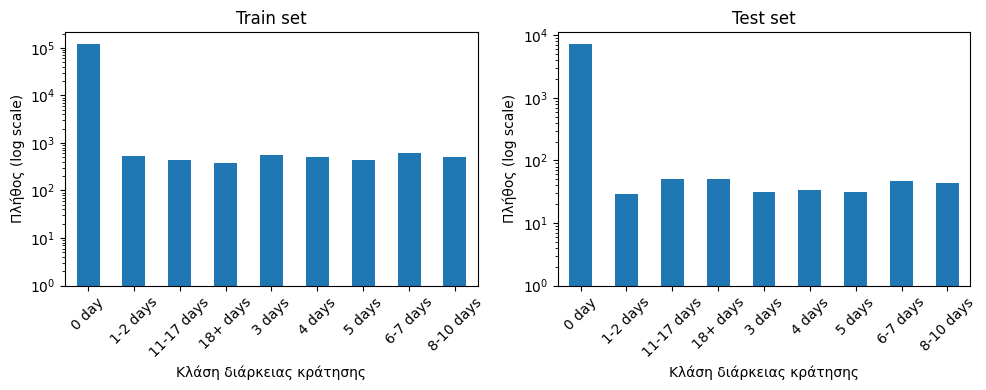

In [14]:
class_order = sorted(train_counts.index.tolist())

train_counts_ord = train_counts.reindex(class_order)
test_counts_ord = test_counts.reindex(class_order)

plt.figure(figsize=(10, 4))

# Train plot
plt.subplot(1, 2, 1)
train_counts_ord.plot(kind="bar", log=True)
plt.title("Train set")
plt.xlabel("Κλάση διάρκειας κράτησης")
plt.ylabel("Πλήθος (log scale)")
plt.xticks(rotation=45)

# Test plot
plt.subplot(1, 2, 2)
test_counts_ord.plot(kind="bar", log=True)
plt.title("Test set")
plt.xlabel("Κλάση διάρκειας κράτησης")
plt.ylabel("Πλήθος (log scale)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Αποθήκευση των τελικών datasets (final, train, test)

Σε αυτό το βήμα αποθηκεύουμε:
- Το τελικό paper-aligned dataset (όλες οι εγγραφές)
- Το train set
- Το test set

Τα αρχεία γράφονται στον φάκελο `API-Data/processed/` ώστε να μπορούν να χρησιμοποιηθούν
στο επόμενο notebook (εκπαίδευση Bayesian Network).


In [15]:
# Paths gia apothikeusi
FINAL_CSV = PROCESSED_DIR / "dataset_paper_final.csv"
TRAIN_CSV = PROCESSED_DIR / "dataset_paper_train.csv"
TEST_CSV  = PROCESSED_DIR / "dataset_paper_test.csv"

# Ftiaxnoume ena "final" dataset (train+test window) i olokliro? 
# Emeis tha kratísoume OLO to df_model xwris dates (gia plirotita)
final_df = df_model.drop(columns=["DateOfFirstVisit_dt"]).copy()

final_df.to_csv(FINAL_CSV, index=False)
train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("Saved:")
print(" -", FINAL_CSV, "rows:", len(final_df))
print(" -", TRAIN_CSV, "rows:", len(train_df))
print(" -", TEST_CSV,  "rows:", len(test_df))


Saved:
 - C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\processed\dataset_paper_final.csv rows: 134842
 - C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\processed\dataset_paper_train.csv rows: 122002
 - C:\Users\georg\Desktop\Ergasia Sgouros_v0.3_Final\API-Data\processed\dataset_paper_test.csv rows: 7483


In [16]:
# Quick check oti ontws apothikeutikan
for p in [FINAL_CSV, TRAIN_CSV, TEST_CSV]:
    print(p.name, "| exists:", p.exists(), "| size (MB):", round(p.stat().st_size / (1024*1024), 2))

tmp_train = pd.read_csv(TRAIN_CSV)
tmp_test = pd.read_csv(TEST_CSV)

print("\nReload check:")
print("Train rows:", len(tmp_train), "cols:", len(tmp_train.columns))
print("Test rows:", len(tmp_test), "cols:", len(tmp_test.columns))


print(tmp_train[TARGET].value_counts())
print("\nNumber of classes:", tmp_train[TARGET].nunique())


dataset_paper_final.csv | exists: True | size (MB): 11.52
dataset_paper_train.csv | exists: True | size (MB): 10.42
dataset_paper_test.csv | exists: True | size (MB): 0.64

Reload check:
Train rows: 122002 cols: 25
Test rows: 7483 cols: 25
duration_class
0 day         118063
6-7 days         613
3 days           544
1-2 days         536
4 days           513
8-10 days        509
11-17 days       426
5 days           426
18+ days         372
Name: count, dtype: int64

Number of classes: 9
